In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS
from gaussian_fit import fit_gaussian, fit_double_gaussian
import matplotlib.ticker as ticker
from matplotlib.path import Path

In [2]:
#这里dir1是pre_131.sav的目录对应0-31，dir2是131.sav的目录对应32-132，exptime是长148的观测时间
def aia_intensity_curve(dir1,dir2,dir3,exptime,wavelenth):
    from scipy.io import readsav
    #这部分先把数据读入进来
    matrices=[]
    data1=readsav(dir1)
    matrix_struct=data1['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    matrices=matrices[69:]#这一步是当时我matrices统一设置成大小为110了，所以存的数据都在后面
    data2=readsav(dir2)
    matrix_struct=data2['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    data3=readsav(dir3)
    matrix_struct=data3['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    #计算平均强度
    intensity=np.zeros(148)
    for i in range(148):
        intensity[i]=np.average(matrices[i])
    #这里去掉曝光时间不一致的点，131和193单独处理
    if wavelenth=='131' or '193':
        threshold=2.90 if wavelenth=='131' else 1.99
        #print(threshold)
        intensity[exptime[:]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(148)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    #归一化
    intensity=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))
    return intensity

intensity=np.zeros((7,148))
name_list=['.94','131','171','193','211','304','335']

for i in range(7):
    path=os.path.join(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2',name_list[i],'*.fits')
    file_list=glob.glob(path)
    exptime=np.zeros(len(file_list))
    for j in range(len(file_list)):
        rsm=fits.open(file_list[j])
        exptime[j]=rsm[1].header['EXPTIME']

    dir1=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\pre_'+name_list[i]+'.sav'
    dir2=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'.sav'
    dir3=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\post_'+name_list[i]+'.sav'
    intensity[i,:]=aia_intensity_curve(dir1,dir2,dir3,exptime[:],name_list[i])
    #print(exptime[:133])

In [3]:
map1=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T204301Z.94.image_lev1.fits')
map2=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T211813Z.94.image_lev1.fits')
map3=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T213913Z.94.image_lev1.fits')
map4=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_generate_Bxyz_r\Br_map.fits')
map5=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211156Z.131.image_lev1.fits')
map6=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211820Z.131.image_lev1.fits')
map7=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212244Z.131.image_lev1.fits')
map8=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\171\aia.lev1_euv_12s.2024-06-18T211822Z.171.image_lev1.fits')

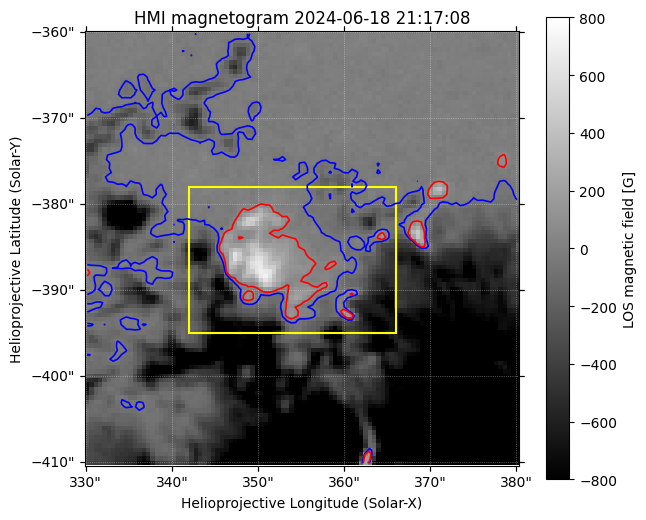

In [4]:
hmi_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits')
map23=sunpy.map.Map(hmi_list[23]).rotate()
bottom_left=SkyCoord(Tx=330*u.arcsec,Ty=-410*u.arcsec,frame=map23.coordinate_frame)
top_right=SkyCoord(Tx=380*u.arcsec,Ty=-360*u.arcsec,frame=map23.coordinate_frame)
sub_map23=map23.submap(bottom_left,top_right=top_right)
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=sub_map23)

plot_map23 = sub_map23.plot(axes=ax, cmap='gray')
plot_map23.set_clim(-800, 800)

# 画出 +200 Gauss 等值线
contours = sub_map23.draw_contours(
    levels=[-50,50] * u.G,
    axes=ax,
    colors=['blue','red'],
    linewidths=1.2,
)
bottom_left2=SkyCoord(Tx=342*u.arcsec,Ty=-395*u.arcsec,frame=map23.coordinate_frame)
top_right2=SkyCoord(Tx=366*u.arcsec,Ty=-378*u.arcsec,frame=map23.coordinate_frame)
sub_map23.draw_quadrangle(bottom_left2,top_right=top_right2,axes=ax,edgecolor='yellow',linewidth=1.5)
fig.colorbar(plot_map23, ax=ax, label='LOS magnetic field [G]')
plt.show()

In [ ]:
hmi_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits')
map23=sunpy.map.Map(hmi_list[0]).rotate()

#裁剪子图画contour
bottom_left=SkyCoord(Tx=330*u.arcsec,Ty=-410*u.arcsec,frame=map23.coordinate_frame)
top_right=SkyCoord(Tx=380*u.arcsec,Ty=-360*u.arcsec,frame=map23.coordinate_frame)
sub_map23=map23.submap(bottom_left,top_right=top_right)
contours = sub_map23.draw_contours(
    levels=[200] * u.G,
    axes=ax,
    colors=['red'],
    linewidths=1.2,
)

#找出contour包围的坐标
# np.indices(shape)：生成数组中每个位置的行号和列号。
# 例如，数据形状是 (2, 3)，则：
# y = [[0, 0, 0],     x = [[0, 1, 2],
#      [1, 1, 1]]          [0, 1, 2]]
# y、x 的形状都与磁图数据相同。
y,x = np.indices(sub_map23.data.shape)#y,x就是对应的这个矩阵的行号和列号
# ravel()：把二维数组展开为一维数组。
# column_stack()：把 x 和 y 并排组合，得到每个像素的 [x, y] 坐标。
# points 的形状为 (像素总数, 2)。
points = np.column_stack([x.ravel(), y.ravel()])

# 为每个像素创建一个布尔标记，初始全部为 False。
# 后面将 contour 内部的像素标记为 True。
inside = np.zeros(len(points), dtype=bool)

# allsegs 是 contours 的属性，不是方法：
# contours.allsegs[等值线层级][该层级中的第几条轮廓]
#
# 因为只画了 levels=[200]*u.G，所以 allsegs[0] 对应 200 G。
# 同一层级可能有多条独立轮廓，下面逐条处理。
# vertices 是一条轮廓的顶点数组，每一行是一个 [x, y]。
for vertices in contours.allsegs[0]:

    # 闭合多边形至少需要三个不同顶点，加上重复的起点，共四个点。
    # np.allclose(a, b)：判断两个数组的对应元素是否在容差内相等。
    # 这里比较首尾顶点，判断轮廓是否闭合。
    if len(vertices) >= 4 and np.allclose(vertices[0], vertices[-1]):

        # Path(vertices)：用轮廓顶点构建一条几何路径。
        # contains_points(points)：逐个判断像素中心是否位于路径内部，
        # 返回与像素数量相同的一维布尔数组。
        #
        # |= 表示“逻辑或后赋值”：位于任意一条闭合轮廓内就保留。
        inside |= Path(vertices).contains_points(points)

# 将一维布尔数组恢复成与磁图相同形状的二维掩膜。
mask = inside.reshape(sub_map23.data.shape)

# np.where(mask)：返回 mask 中为 True 的位置。
# 对二维数组，返回顺序是行号 y、列号 x。
y_in, x_in = np.where(mask)

# 将像素中心坐标转换成太阳坐标，输入需要带像素单位 u.pix。
coords_in = sub_map23.pixel_to_world(x_in * u.pix, y_in * u.pix)
values=sunpy.map.sample_at_coords(sub_map23, coords_in)
maxwell=np.zeros(54)
maxwell[0]=np.sum(values.value)

for i in range(1,54):
    map_i=sunpy.map.Map(hmi_list[i]).rotate()
    with propagate_with_solar_surface():
        sub_map_i=map_i.reproject_to(sub_map23.wcs,preserve_date_obs=True)
    coord_i=sub_map_i.pixel_to_world(x_in * u.pix, y_in * u.pix)
    values=sunpy.map.sample_at_coords(sub_map_i, coord_i)
    maxwell[i]=np.sum(values.value)

In [ ]:
map53=sunpy.map.Map(hmi_list[53]).rotate()
with propagate_with_solar_surface():
    sub_map53=map53.reproject_to(sub_map23.wcs,preserve_date_obs=True)
coord2=sub_map53.pixel_to_world(x_in * u.pix, y_in * u.pix)
print(coord2[0])

<SkyCoord (Helioprojective: obstime=2024-06-18T21:00:15.891, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-06-18T21:00:15.891, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.0072789, 1.50392008, 1.51963542e+11)>): (Tx, Ty) in arcsec
    (358.36856082, -392.98981972)>


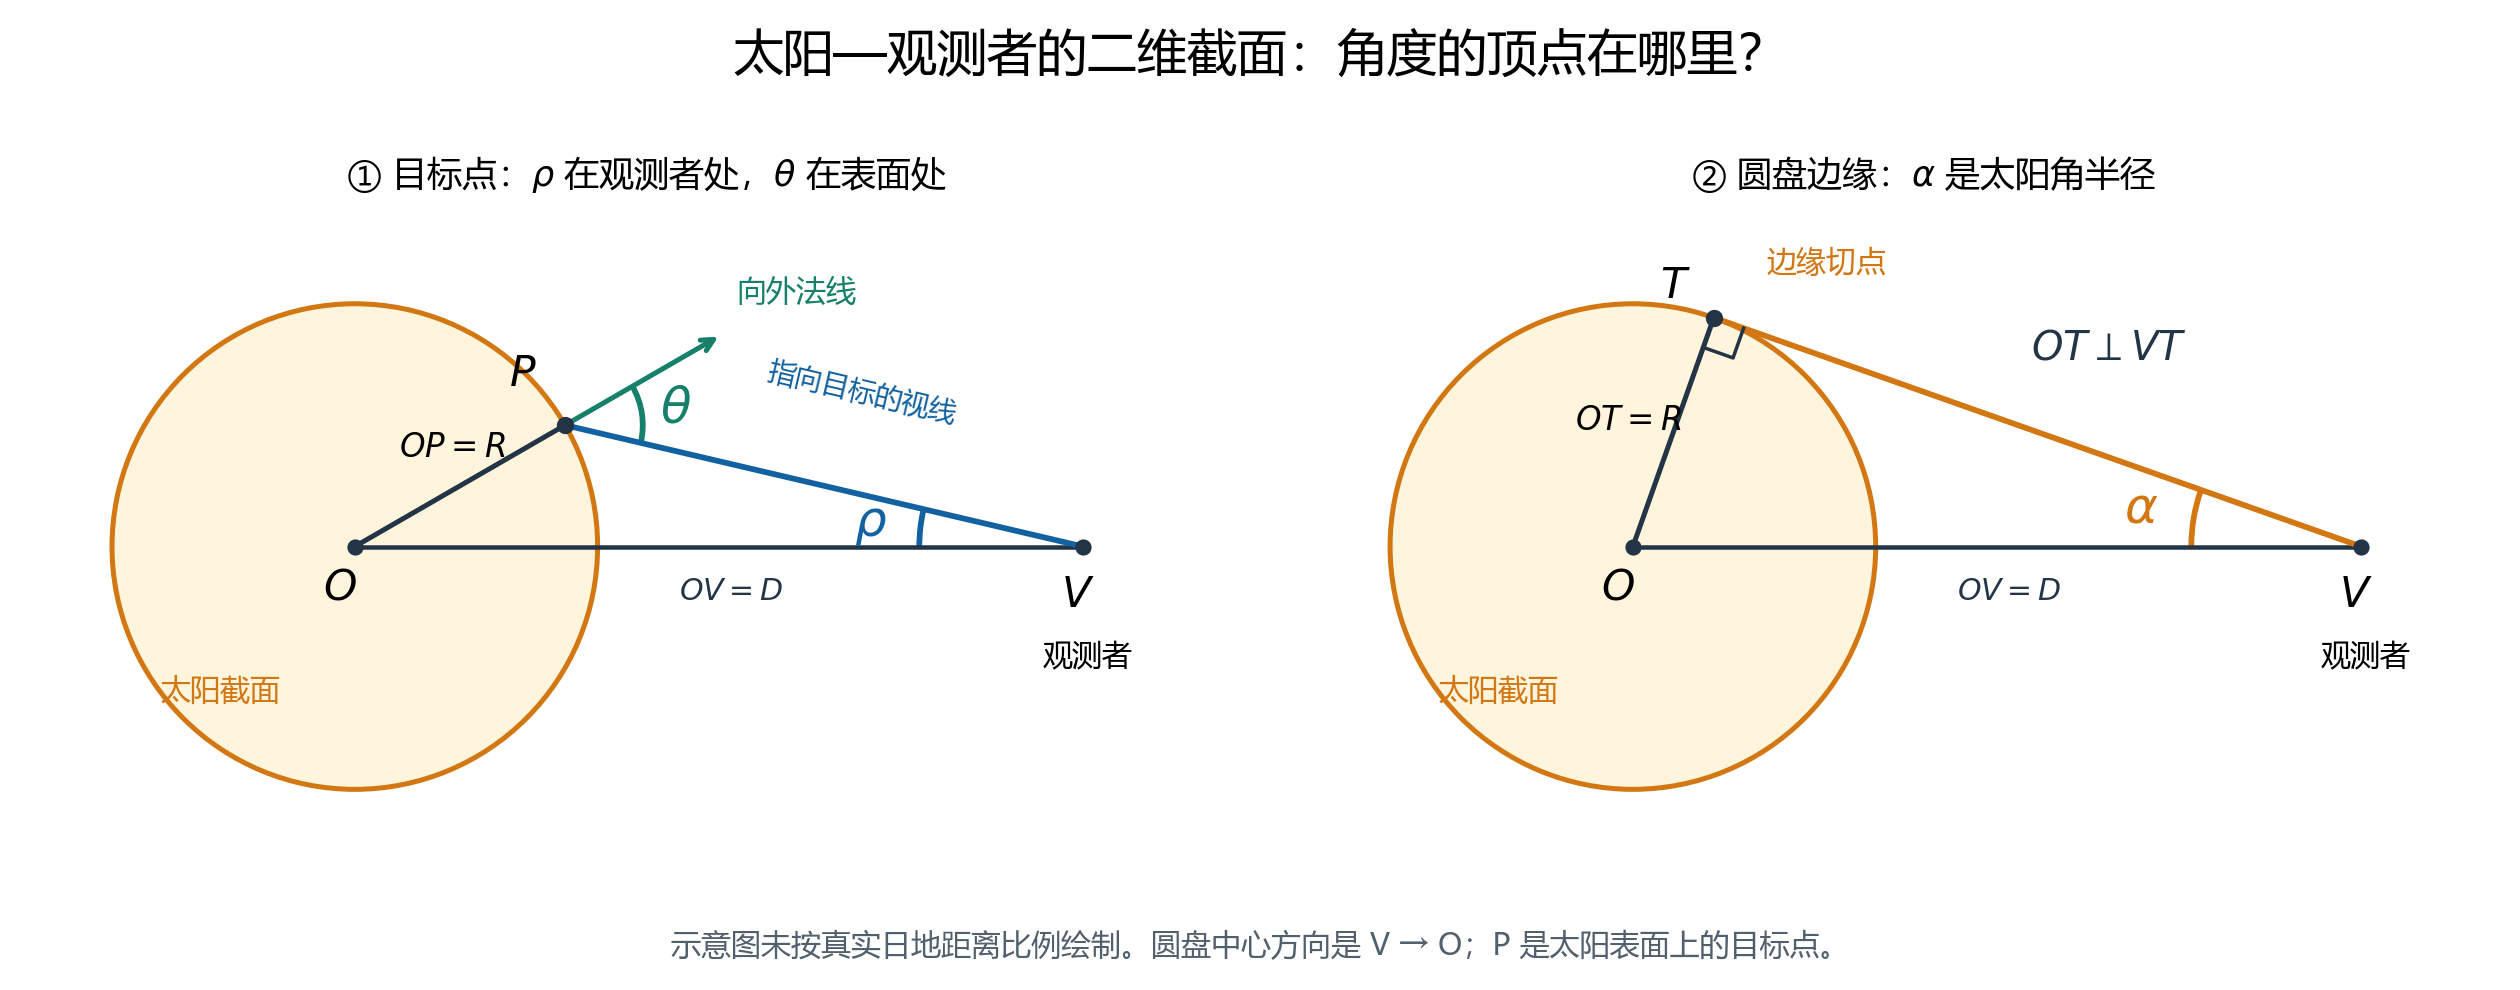

这一段代码是重新投影面积，然后算视向磁场的磁通量变化

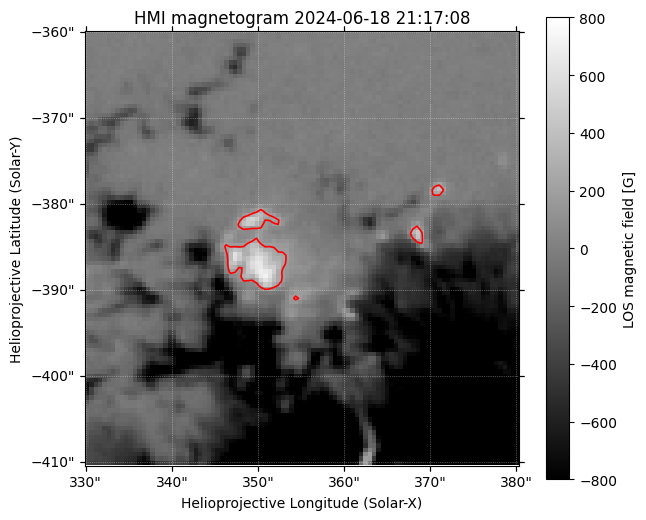

2024-06-18 20:59:53.400000  正视向磁通 = 8.2755e+19 Mx
2024-06-18 21:00:38.400000  正视向磁通 = 8.3334e+19 Mx
2024-06-18 21:01:23.400000  正视向磁通 = 8.3923e+19 Mx
2024-06-18 21:02:08.400000  正视向磁通 = 8.3868e+19 Mx
2024-06-18 21:02:53.400000  正视向磁通 = 8.3551e+19 Mx
2024-06-18 21:03:38.400000  正视向磁通 = 8.3597e+19 Mx
2024-06-18 21:04:23.400000  正视向磁通 = 8.4604e+19 Mx
2024-06-18 21:05:08.400000  正视向磁通 = 8.5805e+19 Mx
2024-06-18 21:05:53.400000  正视向磁通 = 8.5939e+19 Mx
2024-06-18 21:06:38.400000  正视向磁通 = 8.4736e+19 Mx
2024-06-18 21:07:23.400000  正视向磁通 = 8.5404e+19 Mx
2024-06-18 21:08:08.400000  正视向磁通 = 8.6360e+19 Mx
2024-06-18 21:08:53.400000  正视向磁通 = 8.7153e+19 Mx
2024-06-18 21:09:38.400000  正视向磁通 = 8.7565e+19 Mx
2024-06-18 21:10:23.400000  正视向磁通 = 8.6715e+19 Mx
2024-06-18 21:11:08.400000  正视向磁通 = 8.6021e+19 Mx
2024-06-18 21:11:53.400000  正视向磁通 = 8.6780e+19 Mx
2024-06-18 21:12:38.400000  正视向磁通 = 8.7162e+19 Mx
2024-06-18 21:13:23.400000  正视向磁通 = 8.8997e+19 Mx
2024-06-18 21:14:08.400000  正视向磁通 = 8.7634e+19 Mx


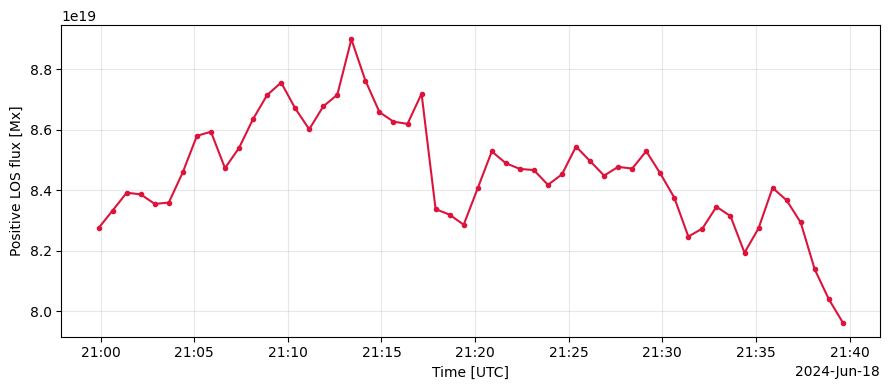

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import astropy.units as u
from astropy.coordinates import SkyCoord
from matplotlib.path import Path

import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface


# ---------- 1. 读取第一帧 ----------
# 此处按文件名排序，适用于文件名中包含规范时间戳的情况。
hmi_list = sorted(glob.glob(
    r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits'
))

if not hmi_list:
    raise FileNotFoundError("没有找到 HMI FITS 文件")

map23 = sunpy.map.Map(hmi_list[23]).rotate()

bottom_left = SkyCoord(
    Tx=330*u.arcsec, Ty=-410*u.arcsec,
    frame=map23.coordinate_frame
)
top_right = SkyCoord(
    Tx=380*u.arcsec, Ty=-360*u.arcsec,
    frame=map23.coordinate_frame
)

sub_map23 = map23.submap(bottom_left, top_right=top_right)


# ---------- 2. 绘制第一帧的 200 G contour ----------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=sub_map23)

im = sub_map23.plot(axes=ax, cmap='gray')
im.set_clim(-800, 800)

contours = sub_map23.draw_contours(
    levels=[200]*u.G,
    axes=ax,
    colors='red',
    linewidths=1.2
)

fig.colorbar(im, ax=ax, label='LOS magnetic field [G]')


# ---------- 3. 获取闭合 contour 内的所有像素 ----------
# np.indices：生成每个像素的行号 y 和列号 x。
y, x = np.indices(sub_map23.data.shape)
points = np.column_stack([x.ravel(), y.ravel()])
inside = np.zeros(len(points), dtype=bool)

# allsegs[0]：第一个等值线层级，即 200 G 的各条轮廓。
for vertices in contours.allsegs[0]:
    # np.allclose：比较首尾顶点是否近似相等，判断轮廓是否闭合。
    if len(vertices) >= 4 and np.allclose(vertices[0], vertices[-1]):
        inside |= Path(vertices).contains_points(points)

mask = inside.reshape(sub_map23.data.shape)

if not mask.any():
    raise ValueError("没有找到闭合 contour 包围的像素，请检查阈值或裁剪范围")

y_in, x_in = np.where(mask)
coords_in = sub_map23.pixel_to_world(x_in*u.pix, y_in*u.pix)

plt.show()


# ---------- 4. 计算参考网格各像素的太阳表面面积 ----------
# separation：计算各像素与日面中心之间的角距离。
disk_center = SkyCoord(
    Tx=0*u.arcsec, Ty=0*u.arcsec,
    frame=sub_map23.coordinate_frame
)
rho = coords_in.separation(disk_center).to_value(u.rad)
solar_radius = sub_map23.rsun_obs.to_value(u.rad)

# 球面几何：mu 为当地表面法线与视线夹角的余弦。
sin_theta = np.sin(rho) / np.sin(solar_radius)
mu0 = np.sqrt(np.clip(1 - sin_theta**2, 0, 1))

if np.any(~np.isfinite(mu0) | (mu0 <= 0)):
    raise ValueError("选中区域包含日面边缘或日面外的位置")

# 参考像素的角尺寸，转换成弧度。
dx = abs(sub_map23.scale.axis1.to_value(u.rad/u.pix))
dy = abs(sub_map23.scale.axis2.to_value(u.rad/u.pix))
D0 = sub_map23.dsun.to_value(u.cm)

# 小角度、远观测者近似；面积单位为 cm²。
area_projected = D0**2 * dx * dy
area_surface = area_projected / mu0

# 后续帧均映射到第一帧网格，并随自转跟踪同一片表面，
# 因此这里的表面面积权重只计算一次。


# ---------- 5. 逐帧计算固定区域内的正视向磁通 ----------
maxwell = np.full(len(hmi_list), np.nan)
times = []

for i, filename in enumerate(hmi_list):

    if i == 23:
        current_map = map23
        aligned_map = sub_map23
    else:
        current_map = sunpy.map.Map(filename)

        # 将当前帧按太阳自转映射回第一帧网格。
        with propagate_with_solar_surface():
            aligned_map = current_map.reproject_to(
                sub_map23.wcs,
                preserve_date_obs=True
            )

    # 使用原图时间；重投影后的坐标网格属于参考帧。
    times.append(current_map.date.utc.datetime)

    # 固定 mask 取值，B 保持为视向磁场，不除以 mu。
    B = (aligned_map.data[mask] * current_map.unit).to_value(u.G)

    # 有缺测时整帧保留为 NaN，避免缺测造成虚假的磁通下降。
    if not np.all(np.isfinite(B)):
        print(f"第 {i+1} 帧固定区域存在缺测，磁通记为 NaN")
        continue

    # 统计固定轮廓内所有正值，不再使用 200 G 阈值。
    positive = B > 0
    maxwell[i] = np.sum(B[positive] * area_surface[positive])

    # G × cm² = Mx
    print(f"{times[-1]}  正视向磁通 = {maxwell[i]:.4e} Mx")


# ---------- 6. 按观测时间排序并画图 ----------
order = np.argsort(np.array(times, dtype='datetime64[us]'))
times = np.asarray(times)[order]
maxwell = maxwell[order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times, maxwell, '.-', color='crimson')

ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Positive LOS flux [Mx]')
ax.grid(alpha=0.3)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.tight_layout()
plt.show()

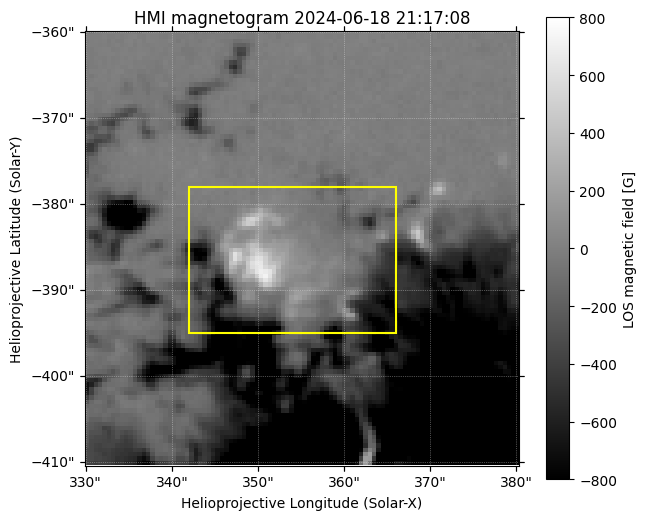

2024-06-18 20:59:53.400000  正 LOS 磁场面积积分 = 1.1773e+20 Mx
2024-06-18 21:00:38.400000  正 LOS 磁场面积积分 = 1.1814e+20 Mx
2024-06-18 21:01:23.400000  正 LOS 磁场面积积分 = 1.1826e+20 Mx
2024-06-18 21:02:08.400000  正 LOS 磁场面积积分 = 1.1780e+20 Mx
2024-06-18 21:02:53.400000  正 LOS 磁场面积积分 = 1.1813e+20 Mx
2024-06-18 21:03:38.400000  正 LOS 磁场面积积分 = 1.1844e+20 Mx
2024-06-18 21:04:23.400000  正 LOS 磁场面积积分 = 1.2062e+20 Mx
2024-06-18 21:05:08.400000  正 LOS 磁场面积积分 = 1.2191e+20 Mx
2024-06-18 21:05:53.400000  正 LOS 磁场面积积分 = 1.2137e+20 Mx
2024-06-18 21:06:38.400000  正 LOS 磁场面积积分 = 1.2018e+20 Mx
2024-06-18 21:07:23.400000  正 LOS 磁场面积积分 = 1.2132e+20 Mx
2024-06-18 21:08:08.400000  正 LOS 磁场面积积分 = 1.2244e+20 Mx
2024-06-18 21:08:53.400000  正 LOS 磁场面积积分 = 1.2384e+20 Mx
2024-06-18 21:09:38.400000  正 LOS 磁场面积积分 = 1.2451e+20 Mx
2024-06-18 21:10:23.400000  正 LOS 磁场面积积分 = 1.2414e+20 Mx
2024-06-18 21:11:08.400000  正 LOS 磁场面积积分 = 1.2373e+20 Mx
2024-06-18 21:11:53.400000  正 LOS 磁场面积积分 = 1.2401e+20 Mx
2024-06-18 21:12:38.400000  正 L

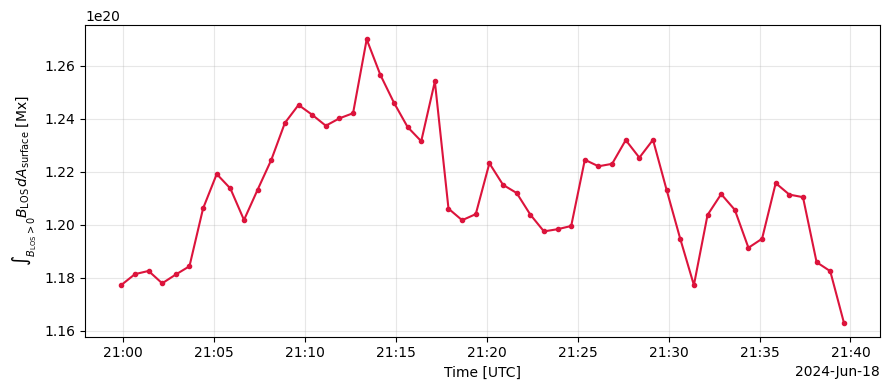

In [5]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface

# 1. 读取参考帧：索引 23，即第 24 帧
hmi_list = sorted(glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits'))
ref_index = 23
if len(hmi_list) <= ref_index:
    raise ValueError(f"仅找到 {len(hmi_list)} 个文件，无法读取索引 {ref_index}")

map23 = sunpy.map.Map(hmi_list[ref_index]).rotate()
bottom_left = SkyCoord(Tx=330*u.arcsec, Ty=-410*u.arcsec, frame=map23.coordinate_frame)
top_right = SkyCoord(Tx=380*u.arcsec, Ty=-360*u.arcsec, frame=map23.coordinate_frame)
sub_map23 = map23.submap(bottom_left, top_right=top_right)

# 2. 定义并绘制要统计的矩形
bottom_left2 = SkyCoord(Tx=342*u.arcsec, Ty=-395*u.arcsec, frame=map23.coordinate_frame)
top_right2 = SkyCoord(Tx=366*u.arcsec, Ty=-378*u.arcsec, frame=map23.coordinate_frame)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=sub_map23)
im = sub_map23.plot(axes=ax, cmap='gray')
im.set_clim(-800, 800)
sub_map23.draw_quadrangle(bottom_left2, top_right=top_right2, axes=ax, edgecolor='yellow', linewidth=1.5)
fig.colorbar(im, ax=ax, label='LOS magnetic field [G]')
plt.show()

# 3. 按像素中心坐标选取矩形内的像素
y, x = np.indices(sub_map23.data.shape)
coords = sub_map23.pixel_to_world(x*u.pix, y*u.pix)
mask = (coords.Tx >= bottom_left2.Tx) & (coords.Tx <= top_right2.Tx)
mask &= (coords.Ty >= bottom_left2.Ty) & (coords.Ty <= top_right2.Ty)
if not mask.any():
    raise ValueError("矩形内没有像素，请检查坐标范围")
coords_in = coords[mask]

# 4. 面积投影矫正：A_surface = A_projected / mu，磁场不矫正
disk_center = SkyCoord(Tx=0*u.arcsec, Ty=0*u.arcsec, frame=sub_map23.coordinate_frame)
rho = coords_in.separation(disk_center).to_value(u.rad)
solar_radius = sub_map23.rsun_obs.to_value(u.rad)
sin_theta = np.sin(rho) / np.sin(solar_radius)
mu0 = np.sqrt(np.clip(1 - sin_theta**2, 0, 1))
if np.any(~np.isfinite(mu0) | (mu0 <= 0)):
    raise ValueError("选中区域包含日面边缘或日面外的位置")

dx = abs(sub_map23.scale.axis1.to_value(u.rad/u.pix))
dy = abs(sub_map23.scale.axis2.to_value(u.rad/u.pix))
D0 = sub_map23.dsun.to_value(u.cm)
area_projected = D0**2 * dx * dy
area_surface = area_projected / mu0  # cm²，小角度、远观测者近似

# 所有帧均映射到参考网格并跟踪同一片太阳表面，使用参考面积权重
maxwell = np.full(len(hmi_list), np.nan)
times = []

# 5. 逐帧统计矩形内的正 LOS 磁场 × 太阳表面面积
for i, filename in enumerate(hmi_list):
    if i == ref_index:
        current_map, aligned_map = map23, sub_map23
    else:
        current_map = sunpy.map.Map(filename)
        with propagate_with_solar_surface():
            aligned_map = current_map.reproject_to(sub_map23.wcs, preserve_date_obs=True)

    times.append(current_map.date.utc.datetime)
    B = (aligned_map.data[mask] * current_map.unit).to_value(u.G)
    if not np.all(np.isfinite(B)):
        print(f"第 {i+1} 帧区域存在缺测，结果记为 NaN")
        continue

    positive = B > 0
    maxwell[i] = np.sum(B[positive] * area_surface[positive])
    print(f"{times[-1]}  正 LOS 磁场面积积分 = {maxwell[i]:.4e} Mx")

# 6. 按实际观测时间排序并画图
order = np.argsort(np.array(times, dtype='datetime64[us]'))
times, maxwell = np.asarray(times)[order], maxwell[order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times, maxwell, '.-', color='crimson')
ax.set_xlabel('Time [UTC]')
ax.set_ylabel(r'$\int_{B_{\rm LOS}>0} B_{\rm LOS}\,dA_{\rm surface}$ [Mx]')
ax.grid(alpha=0.3)
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.tight_layout()
plt.show()

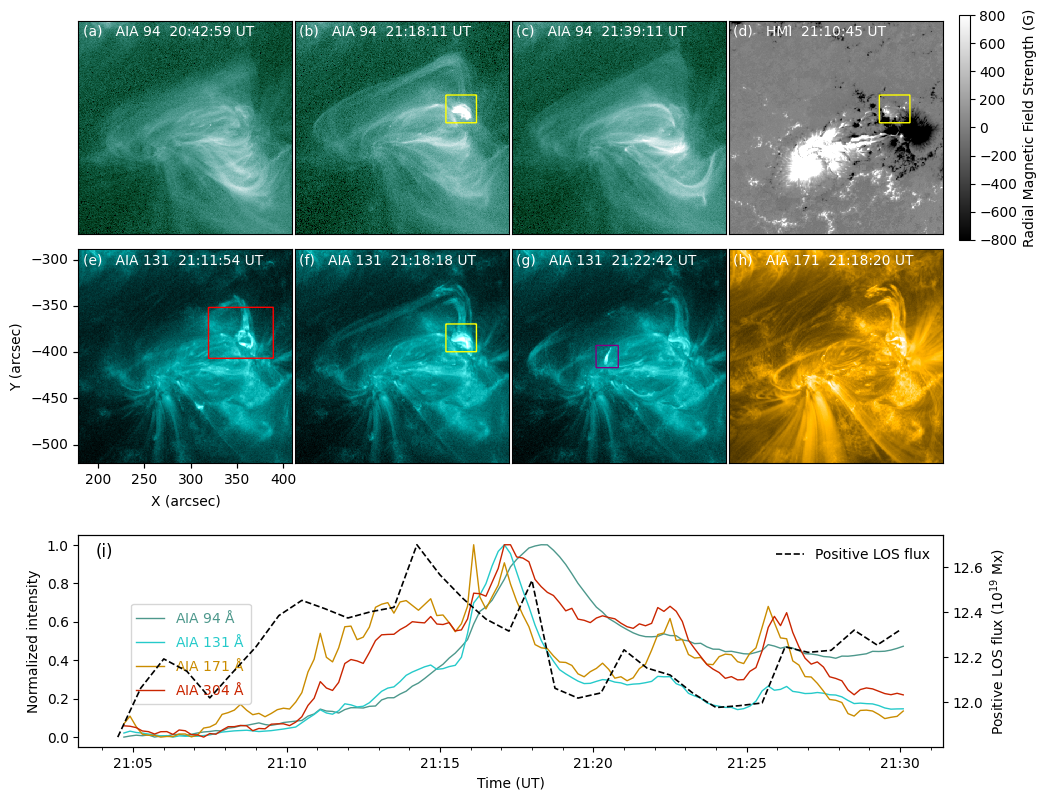

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11.5,9.5))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[7.5, 3.5], hspace=0.2)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 6, subplot_spec=gs[0], wspace=0.02,hspace=0.02,width_ratios=[1,1,1,1,0.05,0.05])
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
#这个标记IRIS观测区域的具体位置，在process_iris.pro文档里有写，导出的矩阵所处的Tx=[320,390]Ty=[-462,-352]范围
#之后读取all_sji_image.sav的时候有一步[330:,:]，把y轴方向裁剪掉了一半，所以现在ty=[-407,-352]
bl2=SkyCoord(Tx=320*u.arcsec, Ty=-407*u.arcsec, frame=map1.coordinate_frame)
tr2=SkyCoord(Tx=390*u.arcsec, Ty=-352*u.arcsec, frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6,map7,map8]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

#对94去除较差自转
with propagate_with_solar_surface():
    for i in range(8):
        if i!=1:#这个时间是21：18：18也就是接近之前算intensity旋转对齐对应的时间,DEM里面对齐的是21：17：00但是就是一分钟，无所谓的
            smap_all[i]=map_all[i].reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[0]=map1.reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[2]=map3.reproject_to(smap_all[1].wcs,preserve_date_obs=True)

ax_all=[]
for i in range(8):
    r=i//4
    c=i%4
    ax=fig.add_subplot(gs_top[r,c],projection=smap_all[i])
    #ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    if i==7:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==0 or i==1 or i==2:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=300
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==4 or i==5 or i==6:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==3:
        im_hmi=smap_all[i].plot(axes=ax_all[i])
        im_hmi.set_clim(-800,800)
    
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第5张图加X Y轴
    if i == 4:   # 左下角
        #标出IRIS的位置
        smap_all[i].draw_quadrangle(bl2,top_right=tr2,edgecolor='red',axes=ax)
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X (arcsec)')
        #ax.set_xlabel('X(arcsecs)',labelpad=1.1)
        ax.set_ylabel('Y (arcsec)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)
        #关掉单位
        ax.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax.coords[1].set_major_formatter('s',show_decimal_unit=False) 
      
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

cax_d=fig.add_subplot(gs_top[0,5])
cbar_d=fig.colorbar(im_hmi,cax=cax_d)
cbar_d.set_label('Radial Magnetic Field Strength (G)')

bl3=SkyCoord(Tx=342*u.arcsec,Ty=-400*u.arcsec,frame=smap_all[3].coordinate_frame)
tr3=SkyCoord(Tx=375*u.arcsec,Ty=-370*u.arcsec,frame=smap_all[3].coordinate_frame)
smap_all[1].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[1])
smap_all[3].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[3])
smap_all[5].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[5])

bl4=SkyCoord(Tx=270*u.arcsec,Ty=-417*u.arcsec,frame=smap_all[4].coordinate_frame)
tr4=SkyCoord(Tx=294*u.arcsec,Ty=-393*u.arcsec,frame=smap_all[4].coordinate_frame)
smap_all[6].draw_quadrangle(bl4,top_right=tr4,edgecolor='purple',axes=ax_all[6])

ax_all[0].text(0.02,0.93,'(a)   AIA 94  20:42:59 UT',color='white',transform=ax_all[0].transAxes,fontsize=10)
ax_all[1].text(0.02,0.93,'(b)   AIA 94  21:18:11 UT',color='white',transform=ax_all[1].transAxes,fontsize=10)
ax_all[2].text(0.02,0.93,'(c)   AIA 94  21:39:11 UT',color='white',transform=ax_all[2].transAxes,fontsize=10)
ax_all[3].text(0.02,0.93,'(d)   HMI  21:10:45 UT',color='white',transform=ax_all[3].transAxes,fontsize=10)
ax_all[4].text(0.02,0.93,'(e)   AIA 131  21:11:54 UT',color='white',transform=ax_all[4].transAxes,fontsize=10)
ax_all[5].text(0.02,0.93,'(f)   AIA 131  21:18:18 UT',color='white',transform=ax_all[5].transAxes,fontsize=10)
ax_all[6].text(0.02,0.93,'(g)   AIA 131  21:22:42 UT',color='white',transform=ax_all[6].transAxes,fontsize=10)
ax_all[7].text(0.02,0.93,'(h)   AIA 171  21:18:20 UT',color='white',transform=ax_all[7].transAxes,fontsize=10)
# ---------------- 下半部分 ----------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=gs[1], wspace=0.02, hspace=0.05,
                                             width_ratios=[1,1,1,1,0.05,0.05])

ax8 = fig.add_subplot(gs_bottom[0,0:4])

name_list=[r'AIA 94 $\mathrm{\AA}$',r'AIA 131 $\mathrm{\AA}$',
           r'AIA 171 $\mathrm{\AA}$',r'AIA 193 $\mathrm{\AA}$',
           r'AIA 211 $\mathrm{\AA}$',r'AIA 304 $\mathrm{\AA}$',r'AIA 335 $\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

#从AIA那几个波段的cmap里采集颜色用来画曲线
color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)
#画七条AIA曲线
for i in range(7):
    if i==1 or i==2 or i==0 or i==5:
        line,=ax8.plot(intensity[i,20:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
        lines.append(line)
legend=ax8.legend(loc='center', bbox_to_anchor=(0.13, 0.44),fontsize=10)
#让legend里的文字颜色和曲线颜色一致
for text,line in zip(legend.get_texts(),lines):
    text.set_color(line.get_color())

corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：30
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12
ax8.set_ylabel('Normalized intensity')
ax8.set_xticks(ticks=corr_x,labels=['21:05','21:10','21:15','21:20','21:25','21:30'])
ax8.text(0.02,0.9,'(i)',color='black',transform=ax8.transAxes,fontsize=12)
import matplotlib.ticker as ticker
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax8.yaxis.set_minor_locator(ticker.NullLocator())       # 禁止 y 轴小刻度
ax8.set_xlabel('Time (UT)')
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig6\aia_image_intensity_curve.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)
# ---------- 在图 (i) 的右侧纵轴添加正磁通曲线 ----------
# maxwell：前面计算得到的正磁通数组，单位 Mx。

# 将当天时间换算为秒，两组时间均按 UT 理解。
aia_plot_start = 21*3600 + 42 + 20*12   # 21:04:42
hmi_start = 21*3600 + 45               # 21:00:45

# 每个 HMI 数据点对应的时间，再换算成 AIA 的横坐标。
hmi_seconds = hmi_start + np.arange(len(maxwell))*45
hmi_x = (hmi_seconds - aia_plot_start)/12

# 保存原横轴范围，避免加入 HMI 后自动扩大时间范围。
#original_xlim = ax8.get_xlim()

# twinx()：共享横轴，在右侧创建一个独立纵轴。
ax_flux = ax8.twinx()

ax_flux.plot(
    hmi_x[5:40],
    np.asarray(maxwell[5:40])/1e19,
    color='black',
    linestyle='--',
    markersize=3,
    linewidth=1.2,
    label='Positive LOS flux'
)

ax_flux.set_ylabel(r'Positive LOS flux ($10^{19}$ Mx)')
ax_flux.tick_params(axis='y', colors='black')
ax_flux.legend(loc='upper right', fontsize=10, frameon=False)

# 恢复原范围；范围之外的 HMI 数据自动裁掉。
#ax8.set_xlim(original_xlim)

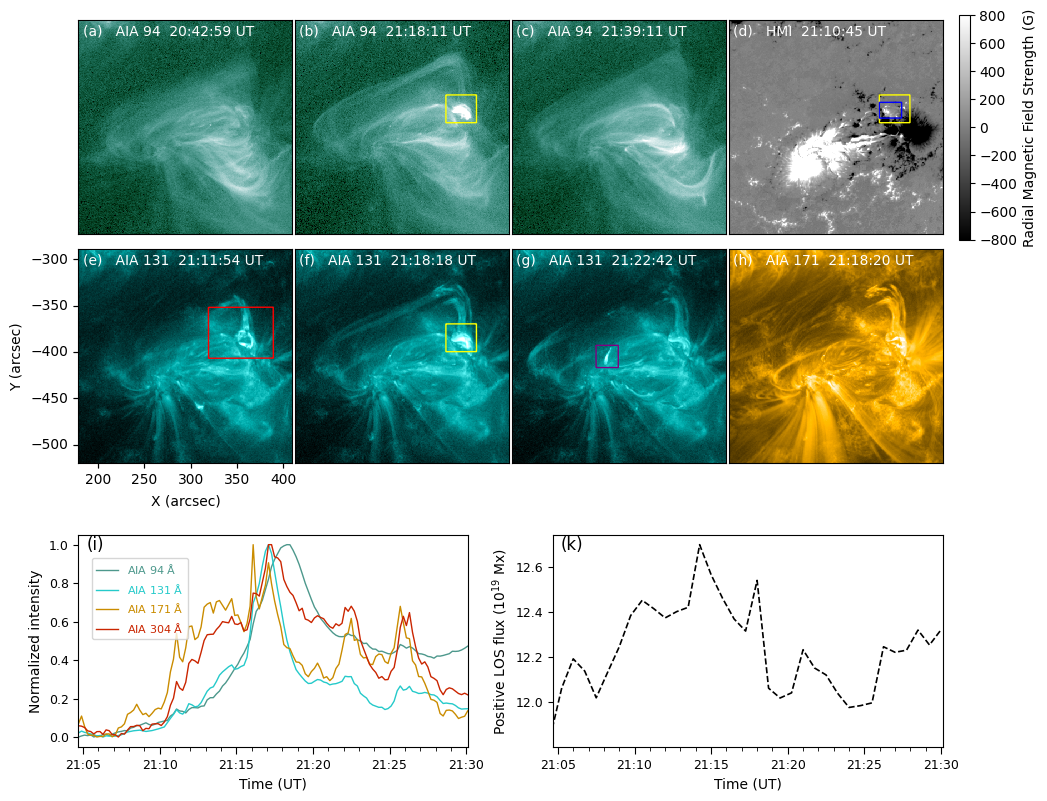

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11.5,9.5))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[7.5, 3.5], hspace=0.2)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 6, subplot_spec=gs[0], wspace=0.02,hspace=0.02,width_ratios=[1,1,1,1,0.05,0.05])
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
#这个标记IRIS观测区域的具体位置，在process_iris.pro文档里有写，导出的矩阵所处的Tx=[320,390]Ty=[-462,-352]范围
#之后读取all_sji_image.sav的时候有一步[330:,:]，把y轴方向裁剪掉了一半，所以现在ty=[-407,-352]
bl2=SkyCoord(Tx=320*u.arcsec, Ty=-407*u.arcsec, frame=map1.coordinate_frame)
tr2=SkyCoord(Tx=390*u.arcsec, Ty=-352*u.arcsec, frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6,map7,map8]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

#对94去除较差自转
with propagate_with_solar_surface():
    for i in range(8):
        if i!=1:#这个时间是21：18：18也就是接近之前算intensity旋转对齐对应的时间,DEM里面对齐的是21：17：00但是就是一分钟，无所谓的
            smap_all[i]=map_all[i].reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[0]=map1.reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[2]=map3.reproject_to(smap_all[1].wcs,preserve_date_obs=True)

ax_all=[]
for i in range(8):
    r=i//4
    c=i%4
    ax=fig.add_subplot(gs_top[r,c],projection=smap_all[i])
    #ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    if i==7:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==0 or i==1 or i==2:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=300
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==4 or i==5 or i==6:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==3:
        im_hmi=smap_all[i].plot(axes=ax_all[i])
        im_hmi.set_clim(-800,800)
    
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第5张图加X Y轴
    if i == 4:   # 左下角
        #标出IRIS的位置
        smap_all[i].draw_quadrangle(bl2,top_right=tr2,edgecolor='red',axes=ax)
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X (arcsec)')
        #ax.set_xlabel('X(arcsecs)',labelpad=1.1)
        ax.set_ylabel('Y (arcsec)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)
        #关掉单位
        ax.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax.coords[1].set_major_formatter('s',show_decimal_unit=False) 
      
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

cax_d=fig.add_subplot(gs_top[0,5])
cbar_d=fig.colorbar(im_hmi,cax=cax_d)
cbar_d.set_label('Radial Magnetic Field Strength (G)')

bl3=SkyCoord(Tx=342*u.arcsec,Ty=-400*u.arcsec,frame=smap_all[3].coordinate_frame)
tr3=SkyCoord(Tx=375*u.arcsec,Ty=-370*u.arcsec,frame=smap_all[3].coordinate_frame)
smap_all[1].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[1])
smap_all[3].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[3])
smap_all[5].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[5])

bl4=SkyCoord(Tx=270*u.arcsec,Ty=-417*u.arcsec,frame=smap_all[4].coordinate_frame)
tr4=SkyCoord(Tx=294*u.arcsec,Ty=-393*u.arcsec,frame=smap_all[4].coordinate_frame)
smap_all[6].draw_quadrangle(bl4,top_right=tr4,edgecolor='purple',axes=ax_all[6])

bl5=SkyCoord(Tx=342*u.arcsec,Ty=-395*u.arcsec,frame=smap_all[3].coordinate_frame)
tr5=SkyCoord(Tx=366*u.arcsec,Ty=-378*u.arcsec,frame=smap_all[3].coordinate_frame)
smap_all[3].draw_quadrangle(bl5,top_right=tr5,edgecolor='blue',axes=ax_all[3])

ax_all[0].text(0.02,0.93,'(a)   AIA 94  20:42:59 UT',color='white',transform=ax_all[0].transAxes,fontsize=10)
ax_all[1].text(0.02,0.93,'(b)   AIA 94  21:18:11 UT',color='white',transform=ax_all[1].transAxes,fontsize=10)
ax_all[2].text(0.02,0.93,'(c)   AIA 94  21:39:11 UT',color='white',transform=ax_all[2].transAxes,fontsize=10)
ax_all[3].text(0.02,0.93,'(d)   HMI  21:10:45 UT',color='white',transform=ax_all[3].transAxes,fontsize=10)
ax_all[4].text(0.02,0.93,'(e)   AIA 131  21:11:54 UT',color='white',transform=ax_all[4].transAxes,fontsize=10)
ax_all[5].text(0.02,0.93,'(f)   AIA 131  21:18:18 UT',color='white',transform=ax_all[5].transAxes,fontsize=10)
ax_all[6].text(0.02,0.93,'(g)   AIA 131  21:22:42 UT',color='white',transform=ax_all[6].transAxes,fontsize=10)
ax_all[7].text(0.02,0.93,'(h)   AIA 171  21:18:20 UT',color='white',transform=ax_all[7].transAxes,fontsize=10)
# ---------------- 下半部分：左侧 AIA，右侧磁通量 ----------------
# ---------------- 下半部分：左侧 AIA，右侧磁通量 ----------------
import matplotlib.ticker as ticker

# 保留与上方图像相同的左右边界，再将底部划分为等宽的两幅图
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=gs[1], wspace=0.02, width_ratios=[1,1,1,1,0.05,0.05])
gs_curves = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_bottom[0,0:4], wspace=0.22)
ax8 = fig.add_subplot(gs_curves[0,0])
ax_flux = fig.add_subplot(gs_curves[0,1], sharex=ax8)

# (i)：AIA 光变曲线，保留原来选取的四个波段
name_list = [r'AIA 94 $\mathrm{\AA}$', r'AIA 131 $\mathrm{\AA}$', r'AIA 171 $\mathrm{\AA}$', r'AIA 193 $\mathrm{\AA}$', r'AIA 211 $\mathrm{\AA}$', r'AIA 304 $\mathrm{\AA}$', r'AIA 335 $\mathrm{\AA}$']
color_list = ['sdoaia94', 'sdoaia131', 'sdoaia171', 'sdoaia193', 'sdoaia211', 'sdoaia304', 'sdoaia335']
color = [plt.get_cmap(name)(0.55) for name in color_list]
lines = []

for i in [0, 1, 2, 5]:
    line, = ax8.plot(intensity[i,20:], color=color[i], label=name_list[i], linewidth=1)
    lines.append(line)

legend = ax8.legend(loc='upper left', bbox_to_anchor=(0.02, 0.92), fontsize=8)
for text, line in zip(legend.get_texts(), lines):
    text.set_color(line.get_color())

ax8.set_ylabel('Normalized intensity')
ax8.text(0.02, 0.93, '(i)', transform=ax8.transAxes, fontsize=12)

# (k)：磁通量曲线，保留原来的时间换算和 [5:40] 数据范围
aia_plot_start = 21*3600 + 42 + 20*12  # 21:04:42 UT
hmi_start = 21*3600 + 45              # 21:00:45 UT
hmi_seconds = hmi_start + np.arange(len(maxwell))*45
hmi_x = (hmi_seconds - aia_plot_start)/12

ax_flux.plot(hmi_x[5:40], np.asarray(maxwell[5:40])/1e19, color='black', linestyle='--', linewidth=1.2)
ax_flux.set_ylabel(r'Positive LOS flux ($10^{19}$ Mx)')
ax_flux.text(0.02, 0.93, '(k)', transform=ax_flux.transAxes, fontsize=12)
ax_flux.ticklabel_format(axis='y', style='plain', useOffset=False)

# 横坐标每个单位代表 12 秒，因此 5 分钟对应 25 个单位
corr_x = (np.arange(6)*300 + 18)/12
ax8.set_xticks(corr_x, labels=['21:05', '21:10', '21:15', '21:20', '21:25','21:30'])
ax8.set_xlim(0, intensity.shape[1] - 21)

# 两幅图共享横轴；将每个 5 分钟区间等分成 5 份
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

for ax_curve in [ax8, ax_flux]:
    ax_curve.set_xlabel('Time (UT)')
    ax_curve.yaxis.set_minor_locator(ticker.NullLocator())
    ax_curve.tick_params(axis='both', which='major', labelsize=9)
    ax_curve.tick_params(axis='x', which='major', length=5)
    ax_curve.tick_params(axis='x', which='minor', length=3)

plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig6\aia_image_intensity_curve.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])



In [11]:
from double_cloud_pixel_fit import fit_double_cloud_cube

result = fit_double_cloud_cube(
    data_cube=rsm[1].data[44:96, 789:806, 1515:1526],
    wavelength=lam00[44:96],
    I0=rsm[1].data[44:96, 797:826, 1540:1569].mean(axis=(1, 2)),
    y_start=789,
    x_start=1515,
    output_dir=r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\double_cloud",
    n_global_runs=30,
)

vL_map = result["vL"]        # 下层云速度，(17, 11)，km/s
vU_map = result["vU"]        # 上层云速度，(17, 11)，km/s
params = result["params"]   # 全部参数，(17, 11, 8)

[1/187] y=789, x=1515, success=True, RMSE=4.0646
[2/187] y=789, x=1516, success=True, RMSE=5.0518
[3/187] y=789, x=1517, success=True, RMSE=4.9374
[4/187] y=789, x=1518, success=True, RMSE=4.0752
[5/187] y=789, x=1519, success=True, RMSE=3.6637
[6/187] y=789, x=1520, success=True, RMSE=4.1423
[7/187] y=789, x=1521, success=True, RMSE=4.4493
[8/187] y=789, x=1522, success=True, RMSE=8.0544
[9/187] y=789, x=1523, success=True, RMSE=5.8599
[10/187] y=789, x=1524, success=True, RMSE=4.4386
[11/187] y=789, x=1525, success=True, RMSE=3.1971
[12/187] y=790, x=1515, success=True, RMSE=2.0055
[13/187] y=790, x=1516, success=True, RMSE=2.7388
[14/187] y=790, x=1517, success=True, RMSE=3.9248
[15/187] y=790, x=1518, success=True, RMSE=4.4011
[16/187] y=790, x=1519, success=True, RMSE=5.1317
[17/187] y=790, x=1520, success=True, RMSE=5.9475
[18/187] y=790, x=1521, success=True, RMSE=2.3031
[19/187] y=790, x=1522, success=True, RMSE=4.2065
[20/187] y=790, x=1523, success=True, RMSE=4.5693
[21/187] 

In [ ]:
#保存result
import pickle
from pathlib import Path

save_path = Path(result["output_dir"]) / "result.pkl"

with open(save_path, "wb") as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"已保存：{save_path}")

In [1]:
#读取result
import pickle
from pathlib import Path

save_path = Path(
    r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image"
    r"\double_cloud\run_20260909_094035_195361\result.pkl"
)

with open(save_path, "rb") as f:
    result = pickle.load(f)

vL_map = result["vL"]
vU_map = result["vU"]
params = result["params"]

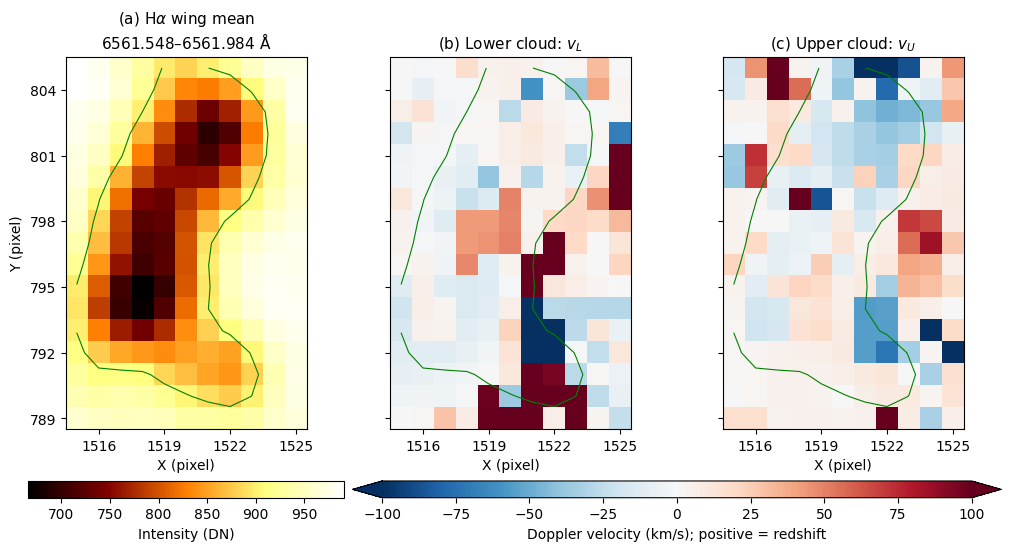

In [2]:
import matplotlib.pyplot as plt
from plot_double_cloud_triptych import plot_double_cloud_triptych

# 本次拟合完成后的输出目录
run_dir = result["output_dir"]

fig, axes, data = plot_double_cloud_triptych(
    run_dir,
    ha_slice=slice(0, 10),
    velocity_limit=100,     # 两张速度图共用 -100～100 km/s 色标
    contour_level=900,    # 三张图叠加同一条 800 DN 等值线
)

plt.show()

In [11]:
# 数据准备
dir = r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm = fits.open(dir)

left_index = 44
right_index = 96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam = lam00[left_index:right_index]  # ±1.5A
I0 = rsm[1].data[left_index:right_index, 797:826, 1540:1569].mean(axis=(1, 2))

print(lam00[39], lam00[44], lam00[54], lam00[96], lam00[101])

lam0 = 6562.8
c_km = 299792.458
vel = (lam - lam0) / lam0 * c_km  # km/s

# 画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime='2024-06-18 21:17:11', observer='earth', frame=frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS, reference_pixel=[rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel, scale=[0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel, telescope='CHASE', instrument='RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=hawing_map.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=hawing_map.coordinate_frame)
sub_hawing_map = hawing_map.submap(left_bottom, top_right=top_right)

pixel1=hawing_map.wcs.world_to_pixel(left_bottom)
print(pixel1)
pixel2=hawing_map.wcs.world_to_pixel(top_right)
print(pixel2)

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735
(array(1368.17839938), array(653.84175767))
(array(1578.98763451), array(864.65098785))


In [9]:
pixel1

PixelPair(x=<Quantity 0.17839938 pix>, y=<Quantity -0.15824233 pix>)

In [ ]:
import importlib
import single_cloud_pixel_fit as sc

importlib.reload(sc)  # 加载修改后的代码

result_single = sc.fit_single_cloud_cube(
    data_cube=rsm[1].data[44:96, 789:806, 1515:1526],
    wavelength=lam00[44:96],
    I0=rsm[1].data[44:96, 797:826, 1540:1569].mean(axis=(1, 2)),
    lam0=None,                  # 根据共同参考背景确定
    background_core_points=5,   # 线心附近的拟合点数
    n_jobs=8,
    n_global_runs=3,
)

print("采用的背景线心：", result_single["lam0"], "Å")

In [13]:
import importlib
import single_cloud_pixel_fit as sc

importlib.reload(sc)  # 加载修改后的代码

result_single = sc.fit_single_cloud_cube(
    data_cube=rsm[1].data[44:96, 653:864, 1368:1578],
    wavelength=lam00[44:96],
    I0=rsm[1].data[44:96, 797:826, 1540:1569].mean(axis=(1, 2)),
    lam0=None,                  # 根据共同参考背景确定
    background_core_points=7,   # 线心附近的拟合点数
    n_jobs=16,
    n_global_runs=30,
)

print("采用的背景线心：", result_single["lam0"], "Å")

Single cloud: 44310 pixels, 16 workers, 30 searches/pixel
C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\single_cloud\run_20260909_200545_057425
Shared wavelength zero point: 6562.86743525 Angstrom (background_core_quadratic)
[1/44310] y=789, x=1515, v=36.714, RMSE=19.59, success=True, elapsed=3.4s
[2/44310] y=789, x=1525, v=34.806, RMSE=14.52, success=True, elapsed=3.4s
[3/44310] y=789, x=1519, v=29.103, RMSE=7.392, success=True, elapsed=3.5s
[4/44310] y=789, x=1526, v=-9.236, RMSE=15.42, success=True, elapsed=3.5s
[5/44310] y=789, x=1529, v=-13.934, RMSE=13.31, success=True, elapsed=3.6s
[6/44310] y=789, x=1516, v=35.262, RMSE=21.96, success=True, elapsed=3.6s
[7/44310] y=789, x=1522, v=33.555, RMSE=5.131, success=True, elapsed=3.6s
[8/44310] y=789, x=1523, v=34.529, RMSE=7.613, success=True, elapsed=3.6s
[9/44310] y=789, x=1521, v=34.189, RMSE=4.587, success=True, elapsed=3.6s
[10/44310] y=789, x=1528, v=-10.286, RMSE=8.539, success=True, elapsed=3.7s
[11/44310] y=789, 

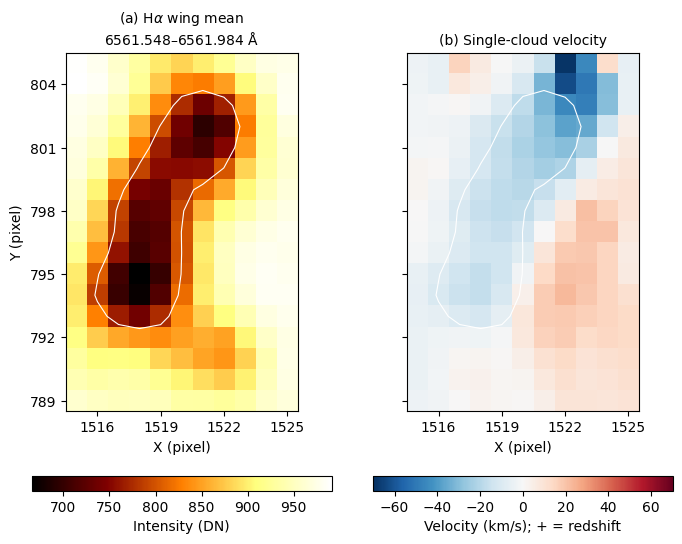

In [17]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from plot_single_cloud_maps import plot_single_cloud_maps

# 已完成的这次单云拟合
run_dir = Path(
    r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image"
    r"\single_cloud\run_20260909_193002_558142_五个点定参考波长"
)

# 恢复完整的 result 字典
with open(run_dir / "result.pkl", "rb") as f:
    result_single = pickle.load(f)

# 绘制 Hα 强度图 + 单云多普勒速度图
fig, axes, data = plot_single_cloud_maps(
    run_dir,
    ha_slice=slice(0, 10),  # 对应原始 FITS 的波长索引 44:54
    velocity_limit=70,     # 色标范围 -70～70 km/s
    contour_level=800,     # 两张图叠加同一条800 DN等值线
    save=False,            # 保存 PNG 和 PDF 到上述目录
)

plt.show()

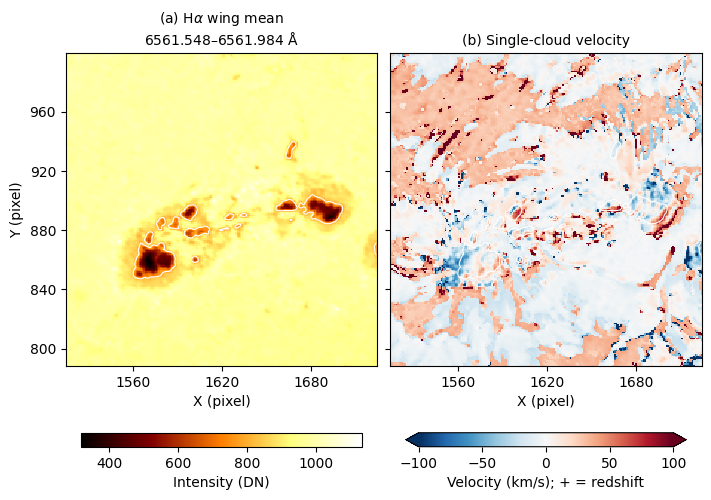

In [15]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from plot_single_cloud_maps import plot_single_cloud_maps

# 已完成的这次单云拟合
run_dir = Path(
    r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image"
    r"\single_cloud\run_20260909_200545_057425"
)

# 恢复完整的 result 字典
with open(run_dir / "result.pkl", "rb") as f:
    result_single = pickle.load(f)

# 绘制 Hα 强度图 + 单云多普勒速度图
fig, axes, data = plot_single_cloud_maps(
    run_dir,
    ha_slice=slice(0, 10),  # 对应原始 FITS 的波长索引 44:54
    velocity_limit=100,     # 色标范围 -70～70 km/s
    contour_level=800,     # 两张图叠加同一条800 DN等值线
    save=False,            # 保存 PNG 和 PDF 到上述目录
)

plt.show()

读取速度图：(17, 11)，y=789:806，x=1515:1526
图片已保存到：C:\Learning\PHD1st\magnetic_reconnecion\paper\fig6


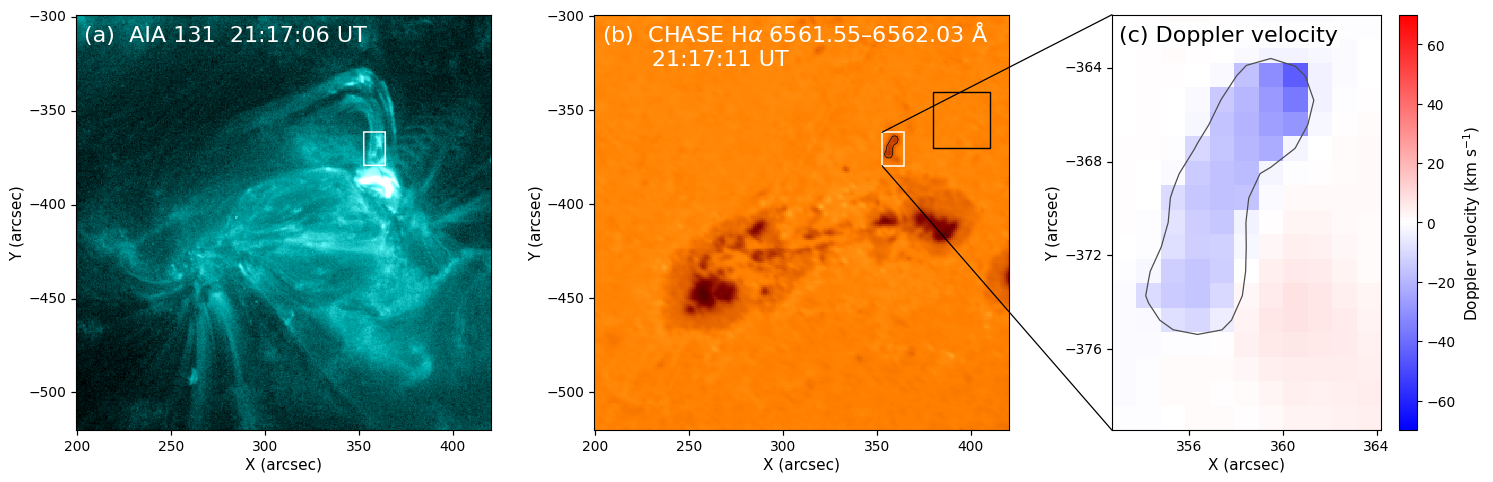

In [18]:
import pickle
from copy import copy
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from matplotlib.colors import Normalize
from matplotlib.patches import ConnectionPatch, Rectangle
import sunpy.map
from sunpy.coordinates import frames

mpl.rcParams.update({'text.usetex': False, 'font.size': 11, 'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

# 1. 路径和显示参数；这里只读取结果、画图，不重新拟合。
run_dir = Path(r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hybrid_cloud\run_20260915_204941_009138')
chase_file = Path(r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits')
aia_file = Path(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits')
save_dir = Path(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig6')
save_figure = True
velocity_limit = 70.0  # 对称色标 [-70, 70] km/s；改成 50 即为 [-50, 50]。
contour_level = 800.0  # 这份已保存结果实际采用的阈值。

# 2. 读取“单云 + 一阶矩”的速度，不用双云结果替换其中的像素。
with (run_dir / 'result_hybrid.pkl').open('rb') as f:
    result_hybrid = pickle.load(f)

velocity = np.asarray(result_hybrid['velocity_stage1'], dtype=float)
ha_roi = np.asarray(result_hybrid['ha_image'], dtype=float)
x_pixels = np.asarray(result_hybrid['x_pixels'], dtype=int)
y_pixels = np.asarray(result_hybrid['y_pixels'], dtype=int)
ny, nx = velocity.shape
assert velocity.shape == ha_roi.shape == (y_pixels.size, x_pixels.size)
assert np.all(np.diff(x_pixels) == 1) and np.all(np.diff(y_pixels) == 1)
x0, x1 = int(x_pixels[0]), int(x_pixels[-1]) + 1
y0, y1 = int(y_pixels[0]), int(y_pixels[-1]) + 1
print(f'读取速度图：{velocity.shape}，y={y0}:{y1}，x={x0}:{x1}')

# 3. CHASE 翼部强度图仍用 44:54；这是成像波段，不改变拟合结果。
with fits.open(chase_file) as hdul:
    chase_header = hdul[1].header.copy()
    hawing = np.mean(hdul[1].section[44:54, :, :], axis=0, dtype=np.float64)

lam00 = chase_header['CRVAL3'] + np.arange(chase_header['NAXIS3']) * chase_header['CDELT3']
chase_time = chase_header['DATE_OBS']
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime=chase_time, observer='earth', frame=frames.Helioprojective)

# 保留原图的 CHASE reference_pixel 和 plate scale，使 a、b、c 沿用同一套配准。
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS, 
                                           reference_pixel=[chase_header['CRPIX1'], chase_header['CRPIX2']] * u.pixel, 
                                           scale=[0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel, telescope='CHASE', instrument='RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)
bottom_left = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=hawing_map.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=hawing_map.coordinate_frame)
sub_hawing_map = hawing_map.submap(bottom_left, top_right=top_right)

# 用同一张 CHASE 图的精确像素裁剪取得 c 图 WCS；submap 的右上像素包含在内。
roi_map = hawing_map.submap([x0, y0] * u.pixel, top_right=[x1 - 1, y1 - 1] * u.pixel)
assert roi_map.data.shape == velocity.shape
assert np.allclose(roi_map.data, ha_roi, rtol=1e-5, atol=1e-4, equal_nan=True), 'FITS 的翼部强度与保存结果不匹配，请核对文件和区域。'

# 4. AIA 131 图像。
aia = sunpy.map.Map(aia_file)
bottom_left = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=aia.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=aia.coordinate_frame)
sub_aia = aia.submap(bottom_left, top_right=top_right)
aia_norm = copy(sub_aia.plot_settings['norm'])
aia_norm.vmin, aia_norm.vmax = 0.01, 2000

# 5. 一行三幅图；c 保持真实像素比例，因此比 a、b 窄。
fig = plt.figure(figsize=(15, 5.4), facecolor='white')
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, nx / ny], left=0.05, right=0.92, bottom=0.16, top=0.96, wspace=0.28)
ax1 = fig.add_subplot(gs[0, 0], projection=sub_aia)
ax2 = fig.add_subplot(gs[0, 1], projection=sub_hawing_map)
ax3 = fig.add_subplot(gs[0, 2], projection=roi_map)
sub_aia.plot(axes=ax1, norm=aia_norm)
sub_hawing_map.plot(axes=ax2, cmap='afmhot', vmin=0, vmax=2 * np.nanmean(sub_hawing_map.data))

velocity_cmap = mpl.colormaps['bwr'].resampled(257).copy()
velocity_cmap.set_bad('0.75')
velocity_norm = Normalize(vmin=-velocity_limit, vmax=velocity_limit)
im = ax3.imshow(np.ma.masked_invalid(velocity), origin='lower', cmap=velocity_cmap, norm=velocity_norm, interpolation='nearest', aspect='equal')
ax3.set_xlim(-0.5, nx - 0.5)
ax3.set_ylim(-0.5, ny - 0.5)

# b 图参考区域黑框，保留原来的位置。
background_bl = SkyCoord(Tx=380 * u.arcsec, Ty=-370 * u.arcsec, frame=hawing_map.coordinate_frame)
background_tr = SkyCoord(Tx=410 * u.arcsec, Ty=-340 * u.arcsec, frame=hawing_map.coordinate_frame)
sub_hawing_map.draw_quadrangle(background_bl, top_right=background_tr, axes=ax2, edgecolor='black', linewidth=1)

# a、b 的白框都沿 c 图的像素外边缘绘制，包含完整的 17 × 11 个像素。
for ax in (ax1, ax2):
    box = Rectangle((-0.5, -0.5), nx, ny, facecolor='none', edgecolor='white', linewidth=1.1, transform=ax.get_transform(roi_map.wcs), zorder=4)
    ax.add_patch(box)

ax2.contour(ha_roi, levels=[contour_level], colors='black', linewidths=0.5, transform=ax2.get_transform(roi_map.wcs), zorder=5)
ax3.contour(ha_roi, levels=[contour_level], colors='0.3', linewidths=0.9, zorder=3)

# 6. 三幅图的坐标轴统一显示太阳角秒坐标。
for ax in (ax1, ax2, ax3):
    ax.set_title('')
    ax.coords[0].set_format_unit(u.arcsec)
    ax.coords[1].set_format_unit(u.arcsec)
    ax.coords[0].set_major_formatter('s',show_decimal_unit=False)
    ax.coords[1].set_major_formatter('s',show_decimal_unit=False)
    ax.coords[0].set_axislabel('X (arcsec)', minpad=0.7)
    ax.coords[1].set_axislabel('Y (arcsec)', minpad=0.7)
    ax.coords[0].set_ticks_position('b')
    ax.coords[1].set_ticks_position('l')
    ax.coords[0].set_ticklabel_position('b')
    ax.coords[1].set_ticklabel_position('l')
    ax.coords[0].set_axislabel_position('b')
    ax.coords[1].set_axislabel_position('l')
    ax.coords.grid(False)

for ax in (ax1, ax2):
    ax.coords[0].set_ticks(spacing=50 * u.arcsec)
    ax.coords[1].set_ticks(spacing=50 * u.arcsec)
ax3.coords[0].set_ticks(spacing=4 * u.arcsec)
ax3.coords[1].set_ticks(spacing=4 * u.arcsec)

# 7. 图题放在各图内部；derived 的拼写和一阶矩方法的英文已调整。
aia_clock = aia.date.strftime('%H:%M:%S')
chase_clock = hawing_map.date.strftime('%H:%M:%S')
ax1.text(0.02, 0.975, f'(a)  AIA 131  {aia_clock} UT', color='white', transform=ax1.transAxes, fontsize=16, va='top', zorder=6)
b_title = rf'(b)  CHASE H$\alpha$ {lam00[44]:.2f}–{lam00[54]:.2f} $\mathrm{{\AA}}$ ' + f'\n       {chase_clock} UT'
ax2.text(0.02, 0.99, b_title, color='white', transform=ax2.transAxes, fontsize=16, va='top', zorder=6)
c_title = '(c) Doppler velocity'
ax3.text(0.025, 0.975, c_title, color='black', transform=ax3.transAxes, fontsize=16, va='top', linespacing=1.2,
          bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2), zorder=6)

# 8. 长方形 colorbar；extend='neither' 去掉上下两端的尖角。
fig.canvas.draw()
pos3 = ax3.get_position()
cax = fig.add_axes([pos3.x1 + 0.012, pos3.y0, 0.012, pos3.height])
cbar = fig.colorbar(im, cax=cax, extend='neither')
cbar.set_label(r'Doppler velocity (km s$^{-1}$)')

# 按你的要求：b 中白框左上、左下，分别连到 c 图左上、左下。
for roi_corner, panel_corner in [((-0.5, ny - 0.5), (0, 1)), ((-0.5, -0.5), (0, 0))]:
    connection = ConnectionPatch(xyA=roi_corner, xyB=panel_corner, coordsA=ax2.get_transform(roi_map.wcs), coordsB='axes fraction',
                                  axesA=ax2, axesB=ax3, color='black', linewidth=0.9, arrowstyle='-', clip_on=False, zorder=5)
    fig.add_artist(connection)

if save_figure:
    save_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_dir / 'aia_chase_single_cloud_moment.pdf', bbox_inches='tight', pad_inches=0.1)
    fig.savefig(save_dir / 'aia_chase_single_cloud_moment.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
    print(f'图片已保存到：{save_dir}')

plt.show()
